In [41]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

# Reproducibility (as much as possible)
np.random.seed(42)
tf.random.set_seed(42)

PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed_data"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Models dir:", MODELS_DIR)


Project root: /Users/borisivanov/Documents/GitHub/sdaIndividualProject/notebooks
Data dir: /Users/borisivanov/Documents/GitHub/sdaIndividualProject/notebooks/data/processed_data
Models dir: /Users/borisivanov/Documents/GitHub/sdaIndividualProject/notebooks/models


In [42]:
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed_data"

order_path = DATA_DIR / "order_header.parquet"
order_header_df = pd.read_parquet(order_path)

order_header_df["createdate"] = pd.to_datetime(order_header_df["createdate"], errors="coerce")
order_header_df = order_header_df.dropna(subset=["createdate"])

print("Loaded!", order_header_df.shape)

# We'll forecast MONTHLY REVENUE (sum of amount_eur per month)
weekly = (
    order_header_df
    .set_index("createdate")["amount_eur"]
    .resample("W-MON")     # weekly on Mondays
    .sum()
    .fillna(0)
)
print(len(weekly))
display(weekly.tail())


weekly = weekly.fillna(0)

print("Monthly series length:", len(weekly))
display(weekly.tail(12))


Loaded! (131297, 38)
467


createdate
2025-08-04    4192.6250
2025-08-11    4995.8085
2025-08-18    4075.0090
2025-08-25    4237.8908
2025-09-01    3748.7345
Freq: W-MON, Name: amount_eur, dtype: float64

Monthly series length: 467


createdate
2025-06-16    4290.31730
2025-06-23    3718.64240
2025-06-30    4279.79390
2025-07-07    3804.46695
2025-07-14    4035.89450
2025-07-21    3808.10000
2025-07-28    5054.46645
2025-08-04    4192.62500
2025-08-11    4995.80850
2025-08-18    4075.00900
2025-08-25    4237.89080
2025-09-01    3748.73450
Freq: W-MON, Name: amount_eur, dtype: float64

Total weeks: 467
Train weeks: 441
Test weeks: 26


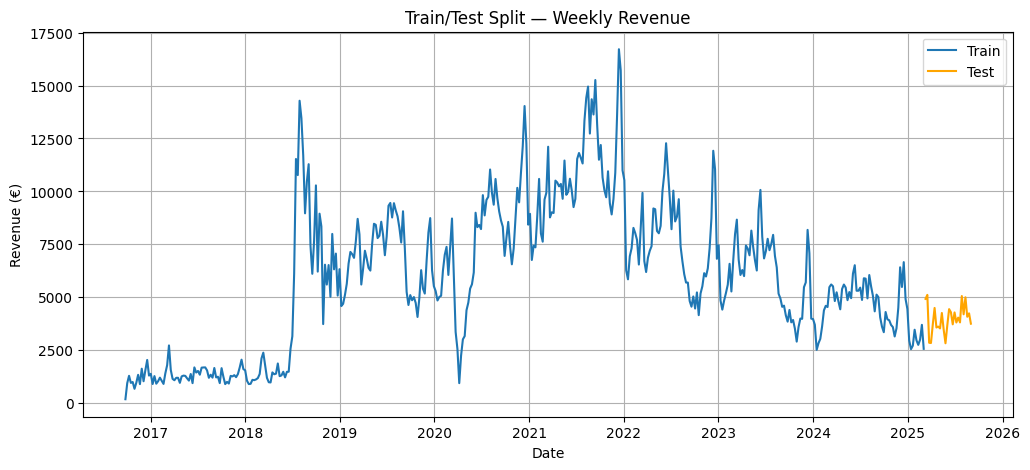

In [43]:
TEST_WEEKS = 26   # ≈ 6 months

# Ensure data is sorted
weekly = weekly.sort_index()

# Train/test split using last 26 weeks
train = weekly.iloc[:-TEST_WEEKS]
test  = weekly.iloc[-TEST_WEEKS:]

print("Total weeks:", len(weekly))
print("Train weeks:", len(train))
print("Test weeks:", len(test))

# Quick visual check
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test", color="orange")
plt.title("Train/Test Split — Weekly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (€)")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# ============================================================
# CELL 4 — XGBoost Feature Engineering (Fourier + calendar events)
# ============================================================

import numpy as np
import pandas as pd

# ----------------------------
# Helper: Fourier seasonal features
# ----------------------------
def fourier_features(index, period, K):
    """
    Generate sin/cos Fourier seasonal components.
    period = full seasonal cycle (365.25 days or 52 weeks)
    K = number of Fourier pairs
    """
    t = np.arange(len(index))
    data = {}

    for k in range(1, K + 1):
        data[f"sin_{period}_{k}"] = np.sin(2 * np.pi * k * t / period)
        data[f"cos_{period}_{k}"] = np.cos(2 * np.pi * k * t / period)

    return pd.DataFrame(data, index=index)


# ----------------------------
# Helper: Calendar events
# ----------------------------
def make_event_flags(index):

    df = pd.DataFrame(index=index)
    df["is_black_friday"] = df.index.isin([
        pd.Timestamp(f"{y}-11-24") + pd.offsets.Week(weekday=4)  # BF = 4th Friday of November
        for y in index.year.unique()
    ])

    df["is_christmas"] = (df.index.month == 12) & (df.index.day >= 20)

    df["is_new_year"] = (df.index.month == 1) & (df.index.day <= 7)

    df["is_summer"] = df.index.month.isin([6,7,8])

    df["is_end_of_quarter"] = df.index.is_quarter_end

    return df.astype(int)


# ----------------------------
# MAIN FEATURE BUILDER
# ----------------------------
def make_features(series, max_lag=12):

    df = pd.DataFrame({"y": series})

    # Lag features (no rolling)
    for lag in range(1, max_lag + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)

    # Date-based features
    df["week_of_year"] = df.index.isocalendar().week.astype(int)
    df["month"] = df.index.month
    df["quarter"] = df.index.quarter
    df["year"] = df.index.year

    # "Strength of week" feature
    # scaled week number between 0–1 to help XGBoost
    df["week_strength"] = df["week_of_year"] / 52

    # Fourier for weekly seasonality (period = 52 weeks)
    fourier_week = fourier_features(df.index, period=52, K=3)

    # Fourier for yearly seasonality (approx 365 days → 52 weeks)
    fourier_year = fourier_features(df.index, period=365.25/7, K=3)

    # Calendar events
    events = make_event_flags(df.index)

    # Combine everything
    df = pd.concat([df, fourier_week, fourier_year, events], axis=1)

    # Drop rows with missing lags
    df = df.dropna()

    return df


# ----------------------------
# Build full feature matrix
# ----------------------------
features = make_features(weekly, max_lag=12)
print("Feature matrix shape:", features.shape)

# Train/test split (aligned with weekly split)
train_df = features.iloc[:-TEST_WEEKS]
test_df  = features.iloc[-TEST_WEEKS:]

X_train = train_df.drop(columns=["y"])
y_train = train_df["y"]

X_test = test_df.drop(columns=["y"])
y_test = test_df["y"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


Feature matrix shape: (455, 35)
X_train: (429, 34)
X_test: (26, 34)


In [45]:
import xgboost as xgb
import optuna
from sklearn.metrics import mean_squared_error


def objective(trial):

    params = {
        "objective": "reg:squarederror",
        "eta": trial.suggest_float("eta", 0.001, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "eval_metric": "rmse",
    }

    num_boost_round = 2000

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest  = xgb.DMatrix(X_test,  label=y_test)

    evals = [(dtrain, "train"), (dtest, "eval")]

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        early_stopping_rounds=50,
        evals=evals,
        verbose_eval=False,
    )

    preds = model.predict(dtest)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse


print("🔍 Starting Optuna hyperparameter search...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("🎯 Best RMSE:", study.best_value)
print("🏆 Best params:", study.best_params)


[I 2025-11-21 21:43:16,544] A new study created in memory with name: no-name-b1646c34-f98a-4041-b445-2f73363fc8d2


🔍 Starting Optuna hyperparameter search...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-21 21:43:16,692] Trial 0 finished with value: 1084.6835403728278 and parameters: {'eta': 0.1591508960216776, 'max_depth': 4, 'subsample': 0.6086856913739438, 'colsample_bytree': 0.8308376595526219, 'min_child_weight': 6, 'gamma': 1.46564761748277, 'reg_alpha': 3.6544753266503633, 'reg_lambda': 2.9359659406948024}. Best is trial 0 with value: 1084.6835403728278.
[I 2025-11-21 21:43:16,797] Trial 1 finished with value: 972.9703118214572 and parameters: {'eta': 0.10480763767723916, 'max_depth': 3, 'subsample': 0.6725247097117091, 'colsample_bytree': 0.5065848001851715, 'min_child_weight': 18, 'gamma': 3.148536085114713, 'reg_alpha': 1.5819080241330974, 'reg_lambda': 4.330055934520568}. Best is trial 1 with value: 972.9703118214572.
[I 2025-11-21 21:43:17,700] Trial 2 finished with value: 1037.8991630418138 and parameters: {'eta': 0.02005428764345453, 'max_depth': 9, 'subsample': 0.9882319824369313, 'colsample_bytree': 0.6577207491161197, 'min_child_weight': 8, 'gamma': 2.097502

🏆 Training final XGB model using best Optuna params...
[0]	train-rmse:3295.99003	eval-rmse:2170.83296
[50]	train-rmse:1253.00039	eval-rmse:988.29484
[100]	train-rmse:887.96447	eval-rmse:857.49296
[150]	train-rmse:751.44607	eval-rmse:837.72914
[197]	train-rmse:669.34489	eval-rmse:835.40972
✔ Final model trained.
📁 Model saved to: /Users/borisivanov/Documents/GitHub/sdaIndividualProject/notebooks/models/xgb_weekly_forecast.model
📉 Residual STD (needed for Monte-Carlo CI): 670.1215
📁 Residual STD + residuals saved.


/var/folders/5c/08hw3f9118z6wxcx_nkdcpym0000gn/T/ipykernel_6290/2070498435.py:44: UserWarning: [21:43:28] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  final_model.save_model(str(model_path))


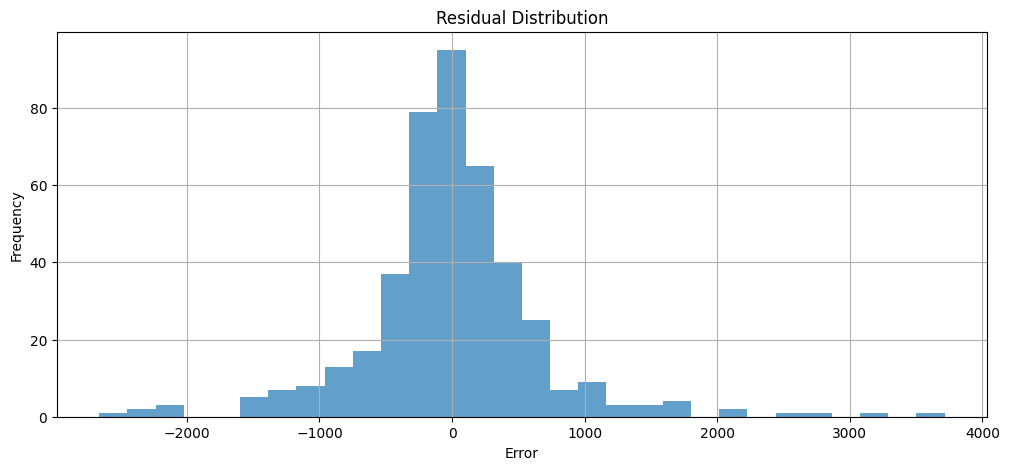

📉 Final Test RMSE: 835.41


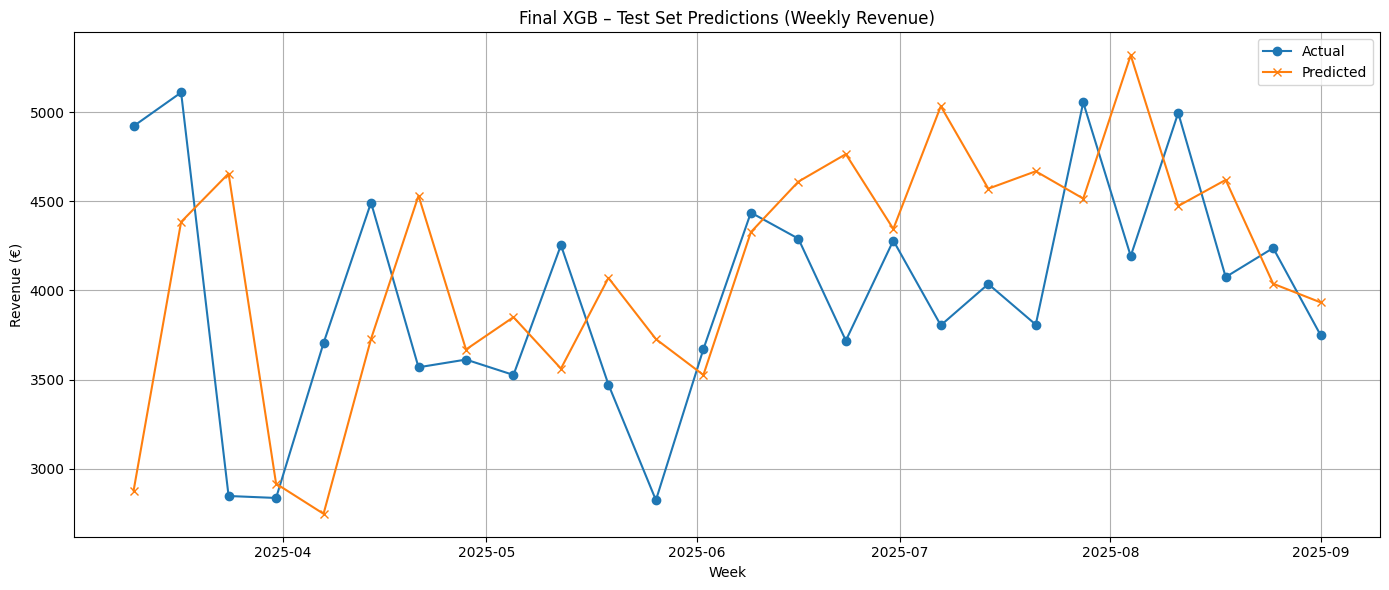

In [46]:
# ============================================================
# CELL 6 — Train Final XGBoost Model with Best Params + Residuals
# ============================================================

import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error
import joblib
import matplotlib.pyplot as plt

print("🏆 Training final XGB model using best Optuna params...")

best_params = study.best_params.copy()

# xgboost convention: "eta" → "learning_rate"
best_params["learning_rate"] = best_params.pop("eta")
best_params["objective"] = "reg:squarederror"
best_params["eval_metric"] = "rmse"

num_boost_round = 2000

# Prepare DMatrix
dtrain_full = xgb.DMatrix(train_df.drop(columns=["y"]), label=train_df["y"])
dtest       = xgb.DMatrix(test_df.drop(columns=["y"]),  label=test_df["y"])

# -----------------------------------------------------------
# Train final model
# -----------------------------------------------------------
final_model = xgb.train(
    best_params,
    dtrain_full,
    num_boost_round=num_boost_round,
    early_stopping_rounds=50,
    evals=[(dtrain_full, "train"), (dtest, "eval")],
    verbose_eval=50,
)

print("✔ Final model trained.")

# -----------------------------------------------------------
# Save model + metadata for Streamlit
# -----------------------------------------------------------
model_path = MODELS_DIR / "xgb_weekly_forecast.model"
final_model.save_model(str(model_path))

np.save(MODELS_DIR / "xgb_features.npy", np.array(X_train.columns.tolist()))

print(f"📁 Model saved to: {model_path}")

# ============================================================
# NEW: Compute residuals & noise distribution
# ============================================================

train_preds_full = final_model.predict(dtrain_full)
residuals = train_df["y"] - train_preds_full
residual_std = residuals.std()

print(f"📉 Residual STD (needed for Monte-Carlo CI): {residual_std:.4f}")

# Save for Streamlit Monte-Carlo forecasting
np.save(MODELS_DIR / "xgb_residual_std.npy", residual_std)
np.save(MODELS_DIR / "xgb_residuals.npy", residuals.values)

print("📁 Residual STD + residuals saved.")

# Optional: residual plot
plt.figure(figsize=(12,5))
plt.hist(residuals, bins=30, alpha=0.7)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# -----------------------------------------------------------
# Evaluate on TEST set
# -----------------------------------------------------------
preds_test = final_model.predict(dtest)
rmse = np.sqrt(mean_squared_error(test_df["y"], preds_test))

print(f"📉 Final Test RMSE: {rmse:,.2f}")

# -----------------------------------------------------------
# Plot Actual vs Predicted (Test)
# -----------------------------------------------------------

plt.figure(figsize=(14,6))
plt.plot(test_df.index, test_df["y"], label="Actual", marker="o")
plt.plot(test_df.index, preds_test, label="Predicted", marker="x")
plt.title("Final XGB – Test Set Predictions (Weekly Revenue)")
plt.xlabel("Week")
plt.ylabel("Revenue (€)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


🔎 Computing SHAP values...
✔ SHAP values computed.


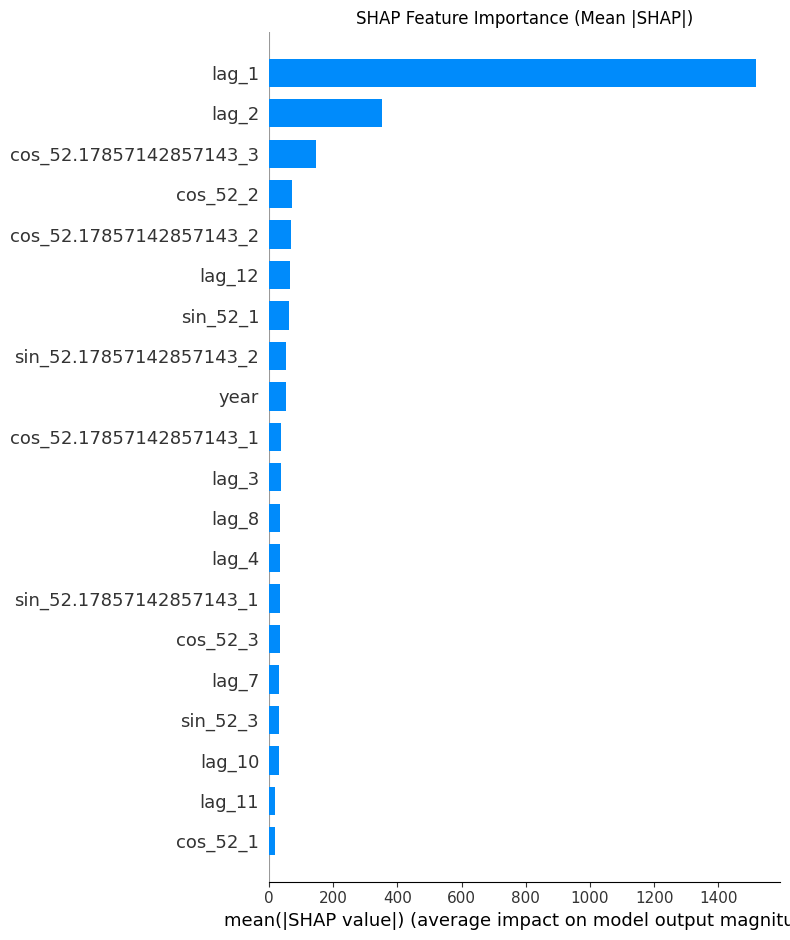

In [47]:
# ============================================================
# CELL 7 — SHAP Explainability for Final XGB Model
# ============================================================

import shap
import matplotlib.pyplot as plt

print("🔎 Computing SHAP values...")

# Ensure we use the same feature matrix as the model saw
X_test_matrix = test_df.drop(columns=["y"])

# Convert to DMatrix for XGB
dtest_shap = xgb.DMatrix(X_test_matrix)

# SHAP TreeExplainer (best for XGBoost)
explainer = shap.TreeExplainer(final_model)

# Compute SHAP values
shap_values = explainer.shap_values(dtest_shap)

print("✔ SHAP values computed.")

# -----------------------------------------------------------
# Bar plot — mean absolute importance
# -----------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_matrix,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (Mean |SHAP|)")
plt.tight_layout()
plt.show()


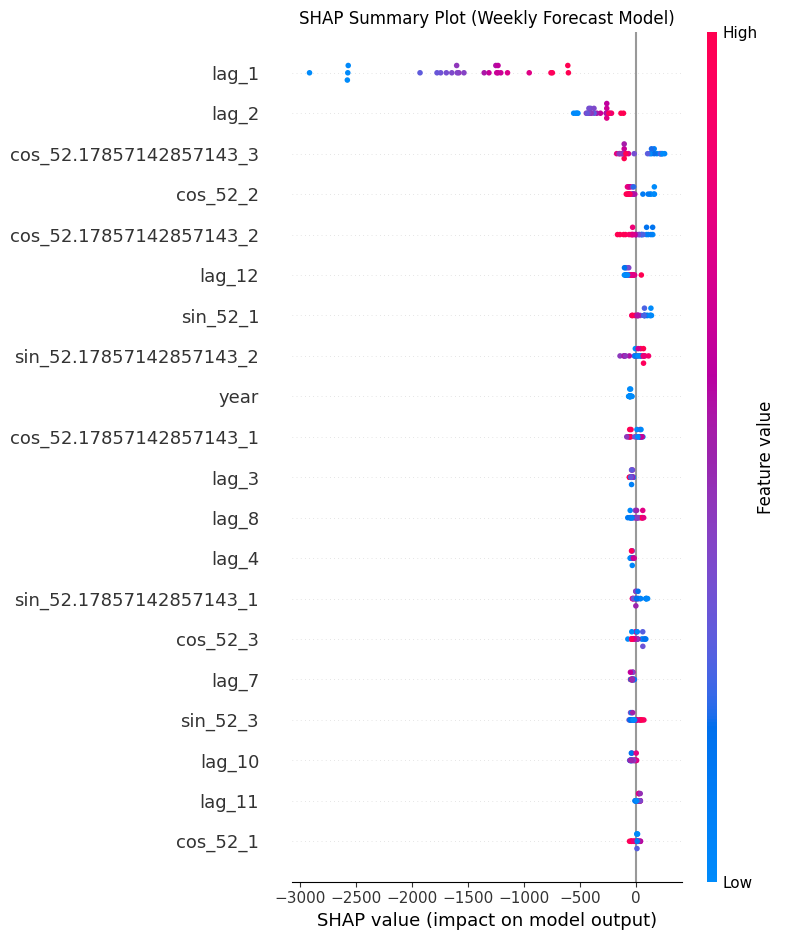

📊 SHAP analysis completed.


In [48]:

# -----------------------------------------------------------
# Beeswarm plot — how each feature influences predictions
# -----------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_matrix,
    show=False
)
plt.title("SHAP Summary Plot (Weekly Forecast Model)")
plt.tight_layout()
plt.show()

print("📊 SHAP analysis completed.")

📂 Loading model + metadata...
✔ Model + features loaded.
✔ Residual STD: 670.1215
⏳ Forecasting weeks: 2025-09-08 00:00:00 → 2026-03-02 00:00:00
🎲 Running Monte Carlo simulations...
✔ Monte Carlo simulation finished.
📁 Saved forecast + CI to xgb_forecast_ci.parquet


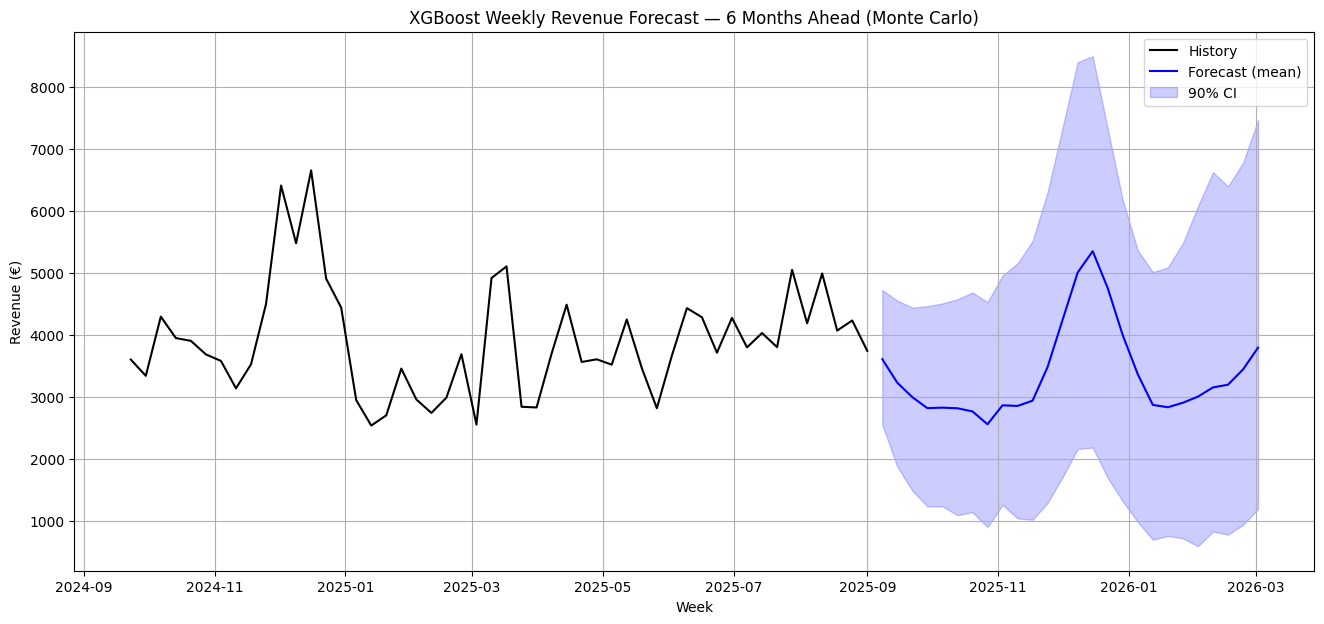

In [49]:
# ============================================================
# CELL 7 — Monte Carlo Forecast (26 weeks ahead)
# ============================================================

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Load trained model + metadata
# -----------------------------------------------------------
print("📂 Loading model + metadata...")

model_path = MODELS_DIR / "xgb_weekly_forecast.model"
features_path = MODELS_DIR / "xgb_features.npy"
residual_std_path = MODELS_DIR / "xgb_residual_std.npy"

final_model = xgb.Booster()
final_model.load_model(str(model_path))

feature_names = np.load(features_path, allow_pickle=True)
residual_std = np.load(residual_std_path)

print("✔ Model + features loaded.")
print(f"✔ Residual STD: {residual_std:.4f}")

# -----------------------------------------------------------
# Forecast configuration
# -----------------------------------------------------------
FORECAST_WEEKS = 26      # 6 months
N_SIMS = 1000            # Monte Carlo runs

# -----------------------------------------------------------
# We need the "most recent window" of data from the FULL dataset,
# not just train-test split.
# -----------------------------------------------------------
last_history = features.copy()   # from Cell 4
last_series = weekly.copy()      # the original weekly series

# -----------------------------------------------------------
# Create dataframe that will hold future forecasted weeks
# -----------------------------------------------------------
future_index = pd.date_range(
    start=last_series.index[-1] + pd.Timedelta(weeks=1),
    periods=FORECAST_WEEKS,
    freq="W-MON"
)

print("⏳ Forecasting weeks:", future_index.min(), "→", future_index.max())

# Store simulation outputs
simulated_paths = np.zeros((N_SIMS, FORECAST_WEEKS))

# ============================================================
# Helper: generate features for a single forecast step
# ============================================================
def build_future_features(current_series, current_index):
    """
    Rebuild a single-row feature set using the same logic as make_features(),
    but only for the NEXT timestep.
    """
    df = pd.DataFrame(index=[current_index])
    df["y"] = np.nan

    # Lags
    for lag in range(1, 13):
        df[f"lag_{lag}"] = current_series.iloc[-lag]

    # Date-based
    df["week_of_year"] = current_index.isocalendar().week
    df["month"] = current_index.month
    df["quarter"] = current_index.quarter
    df["year"] = current_index.year
    df["week_strength"] = df["week_of_year"] / 52

    # Fourier weekly
    t = np.arange(len(current_series))
    for k in range(1, 4):
        df[f"sin_52_{k}"] = np.sin(2 * np.pi * k * len(current_series) / 52)
        df[f"cos_52_{k}"] = np.cos(2 * np.pi * k * len(current_series) / 52)

    # Fourier yearly
    for k in range(1, 3 + 1):
        df[f"sin_{365.25/7}_{k}"] = np.sin(2 * np.pi * k * len(current_series) / (365.25/7))
        df[f"cos_{365.25/7}_{k}"] = np.cos(2 * np.pi * k * len(current_series) / (365.25/7))

    # Calendar events
    df["is_black_friday"] = int(
        current_index in [
            pd.Timestamp(f"{current_index.year}-11-24") +
            pd.offsets.Week(weekday=4)
        ]
    )
    df["is_christmas"] = int((current_index.month == 12) and (current_index.day >= 20))
    df["is_new_year"] = int((current_index.month == 1) and (current_index.day <= 7))
    df["is_summer"] = int(current_index.month in [6, 7, 8])
    df["is_end_of_quarter"] = int(current_index.is_quarter_end)

    return df[feature_names]    # column order aligned with trained model


# ============================================================
# Monte-Carlo Simulation Loop
# ============================================================
print("🎲 Running Monte Carlo simulations...")

for sim in range(N_SIMS):
    series_sim = last_series.copy()

    for step, future_date in enumerate(future_index):

        # Build features for this future week
        X_future = build_future_features(series_sim, future_date)
        d_future = xgb.DMatrix(X_future)

        # Predict base forecast
        base_pred = final_model.predict(d_future)[0]

        # Add noise sampled from residual distribution
        noisy_pred = base_pred + np.random.normal(0, residual_std)

        # Append prediction to simulation series
        series_sim.loc[future_date] = noisy_pred

        simulated_paths[sim, step] = noisy_pred

print("✔ Monte Carlo simulation finished.")

# ============================================================
# Aggregate forecast — mean + 90% CI
# ============================================================
mean_forecast = simulated_paths.mean(axis=0)
lower_90 = np.percentile(simulated_paths, 5, axis=0)
upper_90 = np.percentile(simulated_paths, 95, axis=0)

forecast_df = pd.DataFrame({
    "mean": mean_forecast,
    "lower_90": lower_90,
    "upper_90": upper_90
}, index=future_index)

# Save for Streamlit
forecast_df.to_parquet(MODELS_DIR / "xgb_forecast_ci.parquet")

print("📁 Saved forecast + CI to xgb_forecast_ci.parquet")

# ============================================================
# Plot forecast
# ============================================================

plt.figure(figsize=(16, 7))

plt.plot(last_series.index[-50:], last_series.values[-50:], label="History", color="black")
plt.plot(future_index, mean_forecast, label="Forecast (mean)", color="blue")

plt.fill_between(
    future_index, lower_90, upper_90,
    color="blue", alpha=0.2, label="90% CI"
)

plt.title("XGBoost Weekly Revenue Forecast — 6 Months Ahead (Monte Carlo)")
plt.xlabel("Week")
plt.ylabel("Revenue (€)")
plt.grid(True)
plt.legend()
plt.show()


In [50]:
# ============================================================
# CELL 8 — Prepare Data Files for Streamlit Dashboard
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import json

print("📦 Preparing Streamlit deployment files...")

# -----------------------------
# Ensure model dir exists
# -----------------------------
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1) Save final XGB model
# -----------------------------
model_export_path = MODELS_DIR / "xgb_weekly_forecast.model"
final_model.save_model(str(model_export_path))
print(f"✔ Saved model → {model_export_path}")

# -----------------------------
# 2) Save feature names (column order must match)
# -----------------------------
features_export_path = MODELS_DIR / "xgb_features.npy"
np.save(features_export_path, feature_names)
print(f"✔ Saved feature list → {features_export_path}")

# -----------------------------
# 3) Save residual std (for Monte Carlo)
# -----------------------------
residual_export_path = MODELS_DIR / "xgb_residual_std.npy"
np.save(residual_export_path, residual_std)
print(f"✔ Saved residual std → {residual_export_path}")

# -----------------------------
# 4) Save weekly history (for dashboard plot)
# -----------------------------
history_export_path = MODELS_DIR / "weekly_history.parquet"
weekly.to_frame("y").to_parquet(history_export_path)
print(f"✔ Saved weekly history → {history_export_path}")

# -----------------------------
# 5) Save forecast + confidence intervals
# -----------------------------
forecast_export_path = MODELS_DIR / "xgb_forecast_ci.parquet"
forecast_df.to_parquet(forecast_export_path)
print(f"✔ Saved forecast CI → {forecast_export_path}")

# -----------------------------
# 6) Export metadata for UI
# -----------------------------
metadata = {
    "forecast_weeks": int(FORECAST_WEEKS),
    "num_simulations": int(N_SIMS),
    "last_history_date": str(weekly.index[-1].date()),
    "generated_at": pd.Timestamp.now().isoformat()
}

metadata_export_path = MODELS_DIR / "forecast_metadata.json"
with open(metadata_export_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"✔ Saved metadata → {metadata_export_path}")

# -----------------------------
# Print summary
# -----------------------------
print("\n🎉 Streamlit files ready:")
print(" - Model")
print(" - Feature names")
print(" - Residual STD")
print(" - Weekly history")
print(" - Forecast + CI")
print(" - Metadata JSON")
print("\nYou can now load everything in Streamlit instantly.")


📦 Preparing Streamlit deployment files...
✔ Saved model → /Users/borisivanov/Documents/GitHub/sdaIndividualProject/notebooks/models/xgb_weekly_forecast.model
✔ Saved feature list → /Users/borisivanov/Documents/GitHub/sdaIndividualProject/notebooks/models/xgb_features.npy
✔ Saved residual std → /Users/borisivanov/Documents/GitHub/sdaIndividualProject/notebooks/models/xgb_residual_std.npy
✔ Saved weekly history → /Users/borisivanov/Documents/GitHub/sdaIndividualProject/notebooks/models/weekly_history.parquet
✔ Saved forecast CI → /Users/borisivanov/Documents/GitHub/sdaIndividualProject/notebooks/models/xgb_forecast_ci.parquet
✔ Saved metadata → /Users/borisivanov/Documents/GitHub/sdaIndividualProject/notebooks/models/forecast_metadata.json

🎉 Streamlit files ready:
 - Model
 - Feature names
 - Residual STD
 - Weekly history
 - Forecast + CI
 - Metadata JSON

You can now load everything in Streamlit instantly.


/var/folders/5c/08hw3f9118z6wxcx_nkdcpym0000gn/T/ipykernel_6290/1178968350.py:21: UserWarning: [21:46:45] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  final_model.save_model(str(model_export_path))
